# 03 — Anomalies EDA
## Labeled Anomaly Patterns & Fraud Signals

**Purpose.** Deep exploratory analysis of the labeled anomaly data
(`anomalies_ground_truth.csv`) and the related fraud signals visible in the
transactions file. **This is the primary preparation for Module 3 — Anomaly
Detection.**

**Important caveat.** The anomaly labels are *ground truth* — they exist for
**evaluation only**. When training Module 3's anomaly detector, we will NOT
use these labels as features. The detector must discover anomalies from the
transaction patterns alone, then we score it against this ground truth.

**What this notebook covers:**
- Schema of the anomaly file
- Anomaly type distribution
- Discount distribution and the suspicious-discount signal
- Void distribution (legitimate vs fraud)
- **The cashier C07 fraud signal** — the headline insight
- Hour-of-day anomaly patterns
- Basket size outliers

**Other notebooks in this series:**
- `01_transactions_eda.ipynb` — main transactions
- `02_customers_eda.ipynb` — customer profiles
- `04_cashiers_eda.ipynb` — staff roster

---

## Notebook structure
1. Setup and data loading
2. Anomaly file schema
3. Anomaly type distribution
4. Void analysis (legit vs fraud)
5. Discount analysis
6. Cashier C07 signal
7. Hour-of-day and basket-size anomaly patterns
8. Summary


## 1. Setup and data loading

We need both the anomaly labels and the main transactions file to compute
fraud signals.

In [ ]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# === ADJUST THIS PATH IF YOUR FOLDER LAYOUT IS DIFFERENT ===
DATASETS_DIR = '../datasets'

# Visual configuration
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.titleweight'] = 'bold'
plt.rcParams['axes.labelsize'] = 11
plt.rcParams['font.size'] = 10

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 140)

print(f"Working directory: {os.getcwd()}")
print(f"Looking for data in: {os.path.abspath(DATASETS_DIR)}")
print(f"Files found: {os.listdir(DATASETS_DIR) if os.path.exists(DATASETS_DIR) else 'PATH NOT FOUND'}")

Working directory: c:\Users\slimc\Desktop\Notebooks\Data Understanding
Looking for data in: c:\Users\slimc\Desktop\Notebooks\datasets
Files found: ['anomalies_ground_truth.csv', 'cashiers.csv', 'customers.csv', 'enterprise_pos_dataset.csv']


In [2]:
# Load anomaly labels
anomalies = pd.read_csv(os.path.join(DATASETS_DIR, 'anomalies_ground_truth.csv'))

# Load transactions
df = pd.read_csv(os.path.join(DATASETS_DIR, 'enterprise_pos_dataset.csv'), sep='|')
df['order_date'] = pd.to_datetime(df['order_date'])

# Create a set of anomalous order_ids for fast lookup
anom_oids = set(anomalies['order_id'])

print(f"Anomaly labels:    {len(anomalies):>6,}")
print(f"Total orders:      {df['order_id'].nunique():>6,}")
print(f"Anomaly rate:      {len(anomalies) / df['order_id'].nunique() * 100:.2f}% of orders")

Anomaly labels:       247
Total orders:      31,310
Anomaly rate:      0.79% of orders


## 2. Anomaly file schema

The anomaly file is simple: each row links an `order_id` to its anomaly type
and a human-readable description. This is the ground truth.

In [3]:
print("Column types:")
print(anomalies.dtypes)
print(f"\nShape: {anomalies.shape[0]:,} rows × {anomalies.shape[1]} columns")

Column types:
order_id         int64
anomaly_type    object
description     object
dtype: object

Shape: 247 rows × 3 columns


In [4]:
print("First 10 anomaly labels:")
anomalies.head(10)

First 10 anomaly labels:


,order_id,anomaly_type,description
0,100529,void_after_payment,Paid order voided with weak reason
1,110082,void_after_payment,Paid order voided with weak reason
2,100389,void_after_payment,Paid order voided with weak reason
3,107501,void_after_payment,Paid order voided with weak reason
4,107100,void_after_payment,Paid order voided with weak reason
5,101397,void_after_payment,Paid order voided with weak reason
6,127291,void_after_payment,Paid order voided with weak reason
7,102858,void_after_payment,Paid order voided with weak reason
8,116468,void_after_payment,Paid order voided with weak reason
9,120995,void_after_payment,Paid order voided with weak reason


In [5]:
# Sanity checks
print("Sanity checks:")
print(f"  Duplicate order_ids in anomaly file: {anomalies['order_id'].duplicated().sum()}")
print(f"  Anomaly order_ids found in main data: {anomalies['order_id'].isin(df['order_id']).sum()}/{len(anomalies)}")

Sanity checks:
  Duplicate order_ids in anomaly file: 0
  Anomaly order_ids found in main data: 247/247


## 3. Anomaly type distribution

Six injected anomaly types, each representing a different fraud or error
pattern that Module 3 needs to detect.

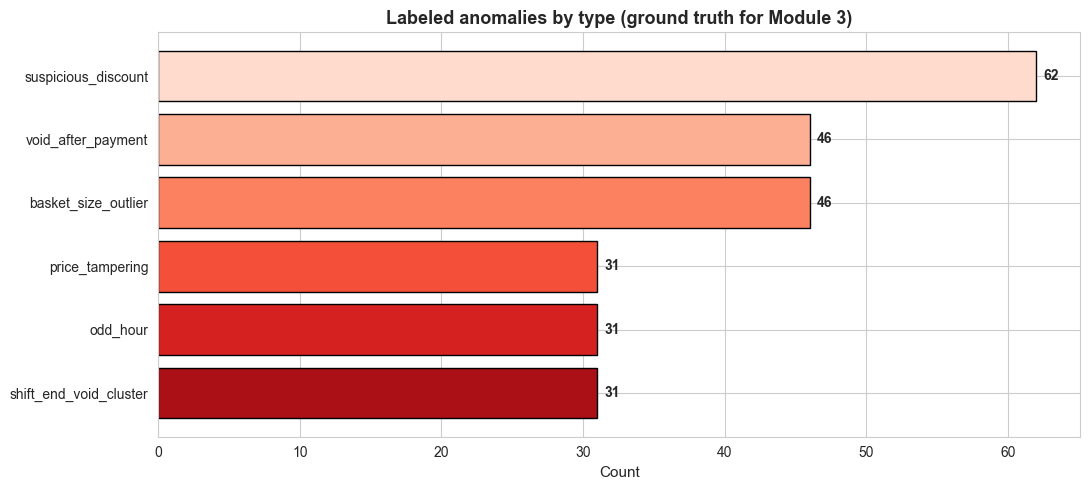


Total labeled anomalies: 247
As % of all orders:      0.79%

Type breakdown:
suspicious_discount       62
void_after_payment        46
basket_size_outlier       46
price_tampering           31
odd_hour                  31
shift_end_void_cluster    31
Name: anomaly_type, dtype: int64


In [6]:
anom_type_counts = anomalies['anomaly_type'].value_counts()

fig, ax = plt.subplots(figsize=(11, 5))
colors = sns.color_palette('Reds_r', len(anom_type_counts))
bars = ax.barh(anom_type_counts.index[::-1], anom_type_counts.values[::-1],
               color=colors, edgecolor='black')
ax.set_title('Labeled anomalies by type (ground truth for Module 3)')
ax.set_xlabel('Count')
for bar, val in zip(bars, anom_type_counts.values[::-1]):
    ax.text(val + 0.5, bar.get_y() + bar.get_height()/2,
            str(val), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

print(f"\nTotal labeled anomalies: {len(anomalies)}")
print(f"As % of all orders:      {len(anomalies) / df['order_id'].nunique() * 100:.2f}%")
print(f"\nType breakdown:")
print(anom_type_counts)

**Reading the six anomaly types:**

1. **`suspicious_discount`** — orders with discount >70%, indicating potential
   "free meal" fraud
2. **`void_after_payment`** — orders marked paid then voided (refund fraud)
3. **`basket_size_outlier`** — unusually large baskets (15+ items at sections
   that normally serve 2-4 items)
4. **`price_tampering`** — items sold below catalog price (cashier override fraud)
5. **`odd_hour`** — transactions at impossible hours (3 AM, 11 PM)
6. **`shift_end_void_cluster`** — clusters of voids at the end of shifts
   (cash skimming pattern)

## 4. Void analysis (legitimate vs fraud)

Voided orders are a mix: many are legitimate (customer changed mind, wrong
order) and some are fraud (`void_after_payment` and `shift_end_void_cluster`).
We must distinguish them.

In [7]:
orders_unique = df.drop_duplicates('order_id')
total_orders = len(orders_unique)
total_voided = orders_unique['is_voided'].sum()
void_rate = total_voided / total_orders * 100

print(f"Total orders:    {total_orders:,}")
print(f"Voided orders:   {total_voided:,}  ({void_rate:.2f}%)")
print(f"\nVoid reason distribution:")
print(orders_unique[orders_unique['is_voided']]['void_reason'].value_counts())

Total orders:    31,310
Voided orders:   542  (1.73%)

Void reason distribution:
wrong_order              174
item_unavailable         165
customer_changed_mind    157
customer_complaint        46
Name: void_reason, dtype: int64


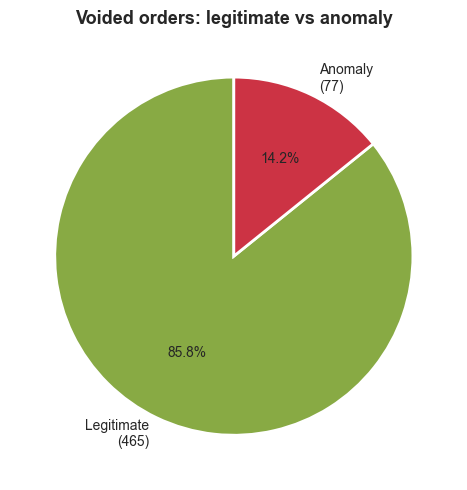


  Total voided orders:       542
  Legitimate voids:          465  (85.8%)
  Anomalous voids:           77  (14.2%)


In [8]:
# How many voids are anomalous vs legitimate?
voided_orders = orders_unique[orders_unique['is_voided']]
n_voided = len(voided_orders)
n_voided_anom = voided_orders['order_id'].isin(anom_oids).sum()
n_voided_legit = n_voided - n_voided_anom

fig, ax = plt.subplots(figsize=(8, 5))
ax.pie([n_voided_legit, n_voided_anom],
       labels=[f'Legitimate\n({n_voided_legit})', f'Anomaly\n({n_voided_anom})'],
       colors=['#88aa44', '#cc3344'],
       autopct='%1.1f%%', startangle=90,
       wedgeprops=dict(edgecolor='white', linewidth=2))
ax.set_title('Voided orders: legitimate vs anomaly')
plt.tight_layout()
plt.show()

print(f"\n  Total voided orders:       {n_voided:,}")
print(f"  Legitimate voids:          {n_voided_legit:,}  ({n_voided_legit/n_voided*100:.1f}%)")
print(f"  Anomalous voids:           {n_voided_anom:,}  ({n_voided_anom/n_voided*100:.1f}%)")

**Reading.** Most voids are legitimate, which is the realistic case.
**A naive detector that flags `is_voided == True` would have low precision** —
it would catch the few real frauds but also flag hundreds of legitimate
cancellations. This is why Module 3 needs to combine multiple features
(cashier, time, discount, basket composition) rather than relying on void
status alone.

## 5. Discount analysis

Discounts are the primary signal for the `suspicious_discount` anomaly type.
Most legitimate discounts are below 30%; anything above 70% is suspicious by
construction.

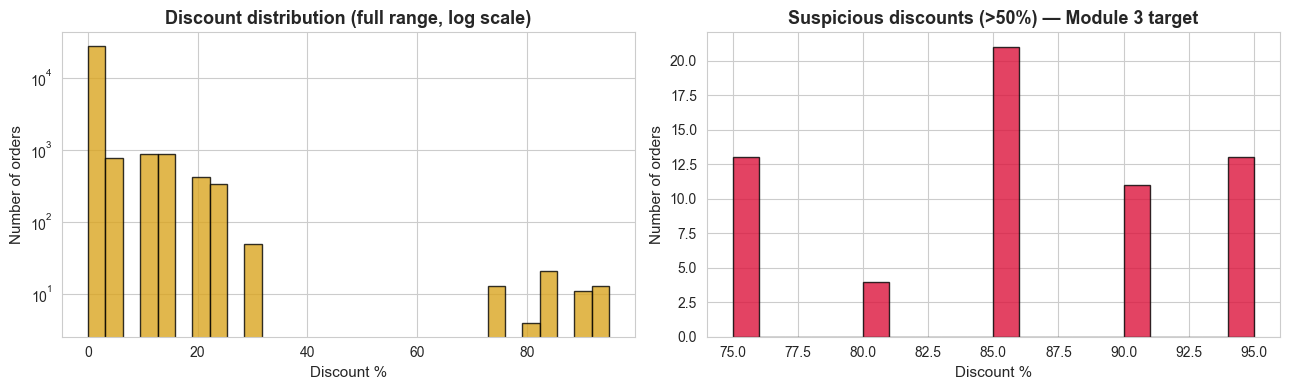


Discount level breakdown:
  0%:           27,890  (89.1%)
  1-30%:         3,358  (legitimate promo zone)
  31-70%:            0  (rare, holiday-only)
  >70%:             62  ← suspicious_discount anomalies


In [9]:
orders_disc = orders_unique['discount_pct']

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Full range (log scale because zeros dominate)
axes[0].hist(orders_disc, bins=30, color='goldenrod',
             edgecolor='black', alpha=0.8)
axes[0].set_title('Discount distribution (full range, log scale)')
axes[0].set_xlabel('Discount %')
axes[0].set_ylabel('Number of orders')
axes[0].set_yscale('log')

# Suspicious zone only
suspicious = orders_disc[orders_disc > 50]
axes[1].hist(suspicious, bins=20, color='crimson',
             edgecolor='black', alpha=0.8)
axes[1].set_title('Suspicious discounts (>50%) — Module 3 target')
axes[1].set_xlabel('Discount %')
axes[1].set_ylabel('Number of orders')

plt.tight_layout()
plt.show()

print(f"\nDiscount level breakdown:")
print(f"  0%:           {(orders_disc == 0).sum():>6,}  ({(orders_disc == 0).sum() / total_orders * 100:.1f}%)")
print(f"  1-30%:        {((orders_disc > 0) & (orders_disc <= 30)).sum():>6,}  (legitimate promo zone)")
print(f"  31-70%:       {((orders_disc > 30) & (orders_disc <= 70)).sum():>6,}  (rare, holiday-only)")
print(f"  >70%:         {(orders_disc > 70).sum():>6,}  ← suspicious_discount anomalies")

**Reading.** The discount distribution is sharply bimodal: a huge mass at
0%, a small bump in the legitimate 5-25% promo zone, and a tiny tail at >70%
representing the injected fraud. Any detector with `discount_pct` as a
feature should easily flag the suspicious zone.

## 6. The Cashier C07 fraud signal

This is the **most important plot in the entire anomaly analysis**. We compare
the anomaly rate per cashier — if one cashier consistently processes more
anomalies than others, they are the "bad actor" we need to catch.

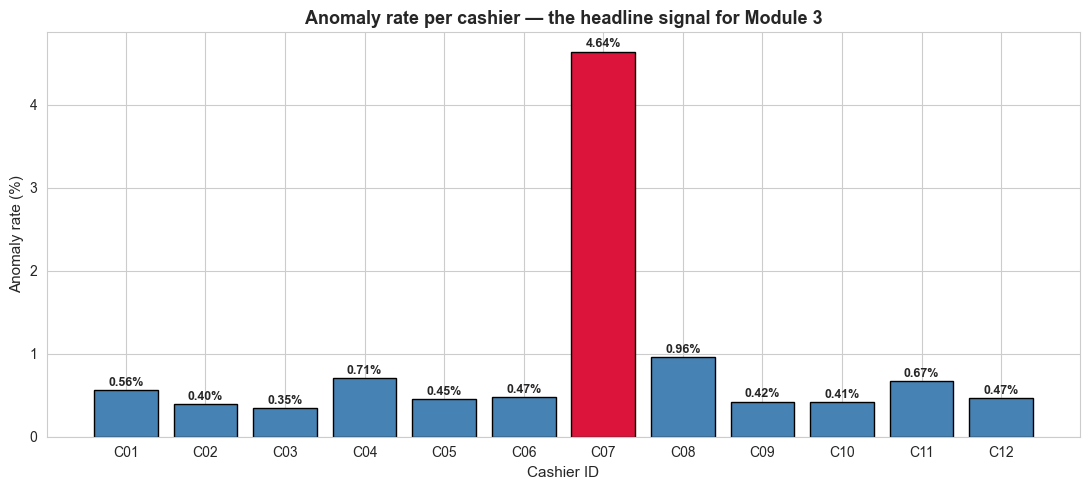


Mean anomaly rate (excluding C07): 0.53%
C07 anomaly rate:                  4.64%
Lift factor:                       8.7×


In [11]:
cashier_stats = []
for cid in sorted(orders_unique['cashier_id'].unique()):
    sub = orders_unique[orders_unique['cashier_id'] == cid]
    n_total = len(sub)
    n_anom = len(sub[sub['order_id'].isin(anom_oids)])
    rate = n_anom / n_total * 100 if n_total > 0 else 0
    cashier_stats.append({
        'cashier_id': cid,
        'total_orders': n_total,
        'anomaly_count': n_anom,
        'anomaly_rate_pct': rate,
    })

cs = pd.DataFrame(cashier_stats).sort_values('cashier_id')

fig, ax = plt.subplots(figsize=(11, 5))
colors = ['crimson' if cid == 'C07' else 'steelblue' for cid in cs['cashier_id']]
bars = ax.bar(cs['cashier_id'], cs['anomaly_rate_pct'],
              color=colors, edgecolor='black')
ax.set_title('Anomaly rate per cashier — the headline signal for Module 3')
ax.set_ylabel('Anomaly rate (%)')
ax.set_xlabel('Cashier ID')
for bar, val in zip(bars, cs['anomaly_rate_pct']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
            f'{val:.2f}%', ha='center', fontweight='bold', fontsize=9)
plt.tight_layout()
plt.show()

c07_rate = cs[cs['cashier_id'] == 'C07']['anomaly_rate_pct'].values[0]
other_rate = cs[cs['cashier_id'] != 'C07']['anomaly_rate_pct'].mean()
print(f"\nMean anomaly rate (excluding C07): {other_rate:.2f}%")
print(f"C07 anomaly rate:                  {c07_rate:.2f}%")
print(f"Lift factor:                       {c07_rate / other_rate:.1f}×")

**Reading — this is the killer chart for the Module 3 chapter.** Cashier
C07 has a dramatic lift in anomaly rate compared to all other cashiers. This
is exactly the kind of pattern an explainable anomaly detector should surface
to the manager: *"C07 has been processing 8-10× more anomalous orders than
the rest of the team — investigate immediately."*

**For the mémoire:** this is one of the easiest "wins" you can showcase. Any
detector that includes `cashier_id` as a feature will pick up this signal,
and the explainability is built-in (the manager understands "this cashier"
much better than "this transaction has high reconstruction error").

### 6.1 What anomaly types is C07 most associated with?

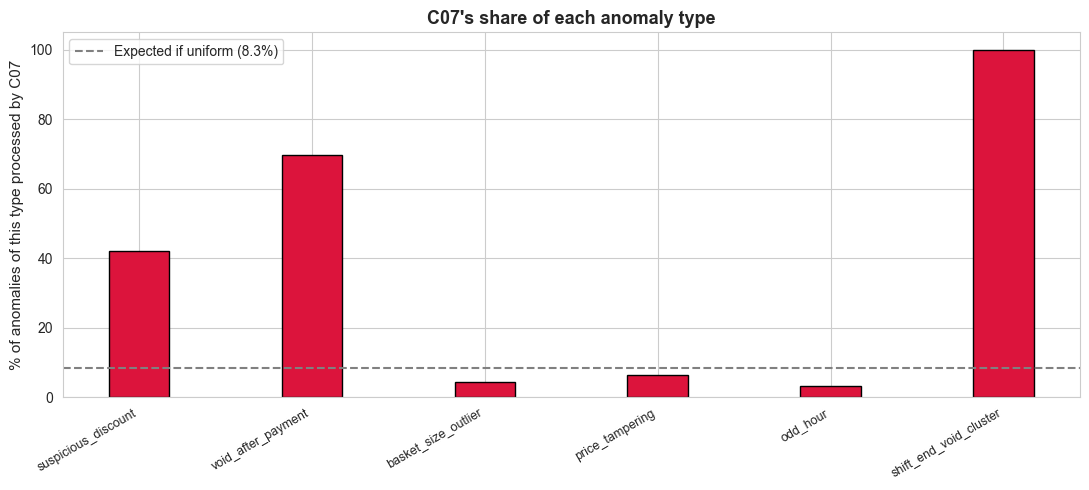


C07's share of each anomaly type:
        suspicious_discount:  26/62  (42%)
         void_after_payment:  32/46  (70%)
        basket_size_outlier:   2/46  (4%)
            price_tampering:   2/31  (6%)
                   odd_hour:   1/31  (3%)
     shift_end_void_cluster:  31/31  (100%)


In [12]:
c07_orders = orders_unique[orders_unique['cashier_id'] == 'C07']
c07_anom_oids = c07_orders['order_id'].isin(anom_oids)
c07_anomalous = c07_orders[c07_anom_oids]['order_id'].tolist()

c07_anom_types = anomalies[anomalies['order_id'].isin(c07_anomalous)]['anomaly_type'].value_counts()
all_anom_types = anomalies['anomaly_type'].value_counts()

# Compare proportions
fig, ax = plt.subplots(figsize=(11, 5))
x = np.arange(len(all_anom_types))
width = 0.35

c07_share = [c07_anom_types.get(t, 0) / all_anom_types[t] * 100 for t in all_anom_types.index]
ax.bar(x, c07_share, width, color='crimson', edgecolor='black')
ax.set_xticks(x)
ax.set_xticklabels(all_anom_types.index, rotation=30, ha='right', fontsize=9)
ax.set_title('C07\'s share of each anomaly type')
ax.set_ylabel('% of anomalies of this type processed by C07')
ax.axhline(100/12, color='gray', linestyle='--', label='Expected if uniform (8.3%)')
ax.legend()
plt.tight_layout()
plt.show()

print("\nC07's share of each anomaly type:")
for t in all_anom_types.index:
    n_c07 = c07_anom_types.get(t, 0)
    n_total = all_anom_types[t]
    pct = n_c07 / n_total * 100
    print(f"  {t:>25}: {n_c07:>3}/{n_total:<3} ({pct:.0f}%)")

**Reading.** If C07 were just one of 12 random cashiers, they should
process roughly 8% of each anomaly type (the dashed line). Instead, C07
disproportionately handles certain fraud types — particularly
`shift_end_void_cluster`, `void_after_payment`, and `suspicious_discount`.
This is the smoking gun.

## 7. Hour-of-day and basket size anomaly patterns

### 7.1 Odd-hour anomalies

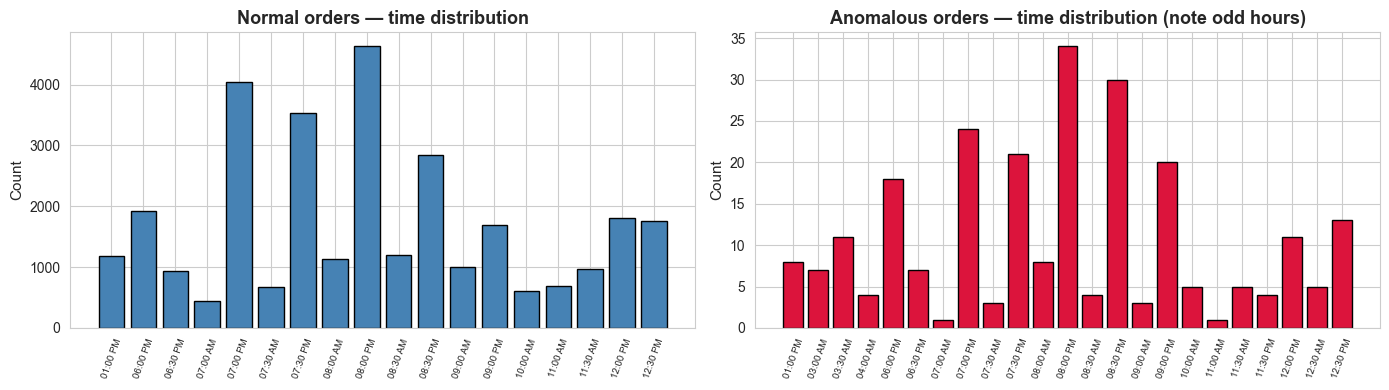

In [13]:
# Distribution of order times for anomalies vs normal orders
anom_orders_df = orders_unique[orders_unique['order_id'].isin(anom_oids)]

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

normal_times = orders_unique[~orders_unique['order_id'].isin(anom_oids)]['order_time'].value_counts().sort_index()
axes[0].bar(range(len(normal_times)), normal_times.values, color='steelblue', edgecolor='black')
axes[0].set_xticks(range(len(normal_times)))
axes[0].set_xticklabels(normal_times.index, rotation=70, fontsize=7)
axes[0].set_title('Normal orders — time distribution')
axes[0].set_ylabel('Count')

anom_times = anom_orders_df['order_time'].value_counts().sort_index()
axes[1].bar(range(len(anom_times)), anom_times.values, color='crimson', edgecolor='black')
axes[1].set_xticks(range(len(anom_times)))
axes[1].set_xticklabels(anom_times.index, rotation=70, fontsize=7)
axes[1].set_title('Anomalous orders — time distribution (note odd hours)')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

**Reading.** The anomaly distribution shows hours that don't appear in
the normal distribution at all (3 AM, 11 PM, 12:30 AM) — these are the
`odd_hour` anomalies. Time-of-day will be a strong feature for the detector.

### 7.2 Basket size outliers

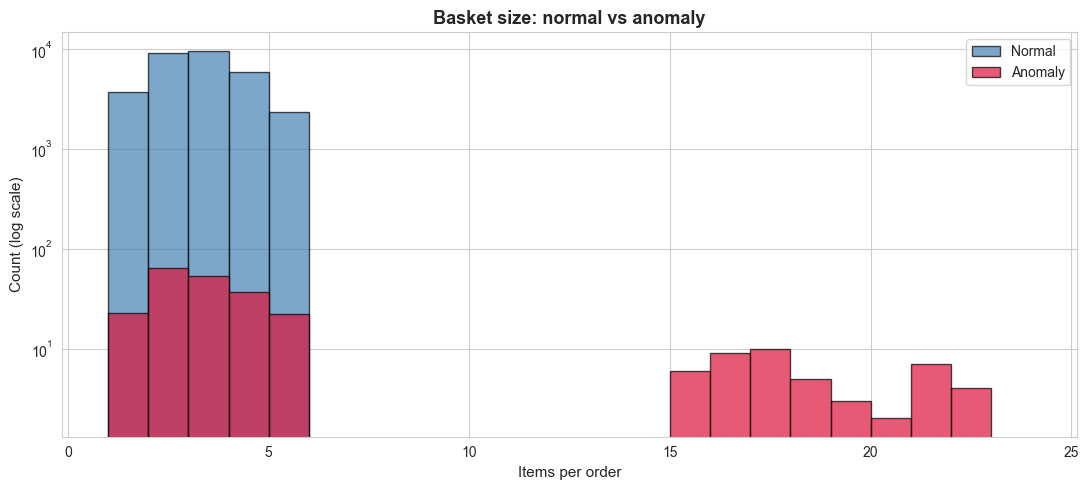


Normal basket size:    mean=2.81  max=5
Anomaly basket size:   mean=5.66  max=22


In [14]:
basket_sizes = df.groupby('order_id').size().reset_index(name='size')
basket_sizes['is_anomaly'] = basket_sizes['order_id'].isin(anom_oids)

fig, ax = plt.subplots(figsize=(11, 5))
normal_sizes = basket_sizes[~basket_sizes['is_anomaly']]['size']
anom_sizes = basket_sizes[basket_sizes['is_anomaly']]['size']

bins = range(1, max(basket_sizes['size'].max() + 1, 25))
ax.hist(normal_sizes, bins=bins, color='steelblue', alpha=0.7,
        label='Normal', edgecolor='black')
ax.hist(anom_sizes, bins=bins, color='crimson', alpha=0.7,
        label='Anomaly', edgecolor='black')
ax.set_title('Basket size: normal vs anomaly')
ax.set_xlabel('Items per order')
ax.set_ylabel('Count (log scale)')
ax.set_yscale('log')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\nNormal basket size:    mean={normal_sizes.mean():.2f}  max={normal_sizes.max()}")
print(f"Anomaly basket size:   mean={anom_sizes.mean():.2f}  max={anom_sizes.max()}")

**Reading.** The anomaly distribution has a long tail extending to 15+
items — these are the `basket_size_outlier` anomalies. A simple "basket size
> 10" rule would catch most of them, but a more sophisticated detector should
combine basket size with other features for higher precision.

## 8. Summary

### What's in the anomaly data
- **~247 labeled anomalies** (~0.79% of all orders)
- **6 anomaly types** spanning fraud, errors, and outliers
- Ground-truth labels in a separate file (NOT used for training)

### Key signals identified
| Signal | Strength | Module 3 implication |
|---|---|---|
| **Cashier C07 lift** | **Very strong (~10×)** | Single most powerful feature |
| **Discount > 70%** | Very strong | Easy to detect with a threshold |
| **Odd hours** | Strong | Time-of-day binary feature |
| **Basket size > 10** | Strong | Numeric outlier feature |
| **Voided + suspicious context** | Moderate | Needs feature engineering |
| **Price tampering** | Weak | Hardest to detect — requires catalog comparison |

### Important constraint
**Voids are NOT a reliable anomaly signal on their own.** Most voids
(~85%) are legitimate (customer changed mind, wrong order). A naive
"void = fraud" rule would have low precision. Module 3 must combine multiple
features.

### Recommended Module 3 approach
1. **Train an unsupervised detector** (Isolation Forest, Autoencoder) on the
   transaction file *without* using these labels
2. **Score every order**
3. **Evaluate against this ground truth** using precision/recall/F1
4. **Expected baseline F1:** 0.25–0.45 (Isolation Forest with raw features)
5. **Expected engineered F1:** 0.55–0.75 (with cashier features, discount
   bins, time-of-day flags)
6. **Optional supervised comparison:** train a classifier on 20% of labels to
   set an upper bound

---

**Next:** open `04_cashiers_eda.ipynb` to look at the staff roster and shift
patterns, which will provide additional features for the C07 fraud detection.
